In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

from dpks import QuantMatrix
from dfmodel import DigitalFamilyBinary


In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [3]:
proteomics_data_train = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

In [4]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)

In [5]:
X, y = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))


In [6]:
y['label'].value_counts()

label
1    465
0    215
Name: count, dtype: int64

In [7]:
protein_columns = X.columns.to_list()

In [8]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

In [9]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

clinical_data_train[continuous_clinical_columns] = clinical_imputer.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[["mental_status_ambulance"]] = constant_imputer.fit_transform(clinical_data_train[["mental_status_ambulance"]])

clinical_data_train[continuous_clinical_columns] = clinical_scaler.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[['sex']] = sex_scaler.fit_transform(clinical_data_train[['sex']])


In [11]:
clinical_data_train['resp_dysfunction'] =  np.where(
    clinical_data_train['sofa_resp_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_resp_day3'] > 0, 1, 0
    )
)

clinical_data_train['renal_dysfunction'] = np.where(
    clinical_data_train['sofa_renal_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_renal_day2'] > 0, 1, 0
    )
)

clinical_data_train['cardiovasc_dysfunction'] = np.where(
    clinical_data_train['sofa_cardiovasc_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cardiovasc_day3'] > 0, 1, 0
    )
)

clinical_data_train['coag_dysfunction'] = np.where(
    clinical_data_train['sofa_coag_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_coag_day3'] > 0, 1, 0
    )
)

clinical_data_train['cns_dysfunction'] = np.where(
    clinical_data_train['sofa_cns_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cns_day3'] > 0, 1, 0
    )
)

clinical_data_train['liver_dysfunction'] = np.where(
    clinical_data_train['sofa_liver_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_liver_day3'] > 0, 1, 0
    )
)

In [17]:
import anndata as ad

clinical_adata = ad.AnnData(
    X=clinical_data_train[clinical_columns],
    obs=clinical_data_train.set_index("injection")
)

protein_adata = ad.AnnData(
    X=X,
    obs=quant_matrix_train.quantitative_data.var.set_index("sample")
)

In [18]:
import muon as mu

mdata = mu.MuData(
    {
        "proteomics": protein_adata,
        "clinical": clinical_adata,
    }
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leide

In [19]:
mu.tl.mofa(
    mdata,
    outfile="clinprot_model"
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='proteomics' group='group1' with N=680 samples and D=287 features...
Loaded view='clinical' group='group1' with N=680 samples and D=13 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weig

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/run/entry_point.py:66: SyntaxWarning: invalid escape sequence '\/'
  banner = """
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/core/utils.py:50: SyntaxWarning: invalid escape sequence '\m'
  """Diagonal of :math:`\mathrm A\mathrm B^\intercal`.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/core/distributions/multivariate_gaussian.py:243: SyntaxWarning: invalid escape sequence '\ '
  """
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/core/nodes/nongaussian_nodes.py:169: SyntaxWarning: invalid escape sequence '\p'
  """
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/


Converged!



#######################
## Training finished ##
#######################


Saving model in clinprot_model...
Saved MOFA embeddings in .obsm['X_mofa'] slot and their loadings in .varm['LFs'].


In [24]:
mofa_columns = []

for i in range(mdata.obsm['X_mofa'].shape[1]):

    clinical_data_train[f"MOFA {i}"] = mdata.obsm['X_mofa'][:, i]

    mofa_columns.append(f"MOFA {i}")



In [25]:
mdata.obsm['X_mofa']

array([[-2.13403927e+00, -2.57929035e+00, -1.57381260e+00, ...,
         5.13621384e-13,  6.12403523e-13,  1.42050883e-11],
       [-8.94144274e-01, -4.09476625e-01, -1.64333205e+00, ...,
         1.22687873e-13, -9.28475522e-13,  8.06715896e-12],
       [ 7.22838098e-01,  1.92847849e+00, -1.37077409e+00, ...,
        -1.32921480e-12,  3.16945654e-12, -5.77722381e-11],
       ...,
       [ 1.66459027e+00,  1.78452942e+00, -1.49580674e+00, ...,
         6.14537046e-13, -2.11910118e-12,  3.00151265e-11],
       [-9.65558229e-01,  7.23062855e-01, -2.65374647e-01, ...,
         2.68176726e-12, -5.97985473e-12,  1.14980042e-10],
       [ 2.17570363e-01,  1.10480954e+00, -1.32051102e+00, ...,
        -3.01565601e-12,  6.99638008e-12, -1.30680132e-10]])

In [28]:
import mofax as mofa

In [29]:
model = mofa.mofa_model("clinprot_model")
model

MOFA+ model: clinprot model
Samples (cells): 680
Features: 300
Groups: group1 (680)
Views: clinical (13), proteomics (287)
Factors: 10
Expectations: W, Z

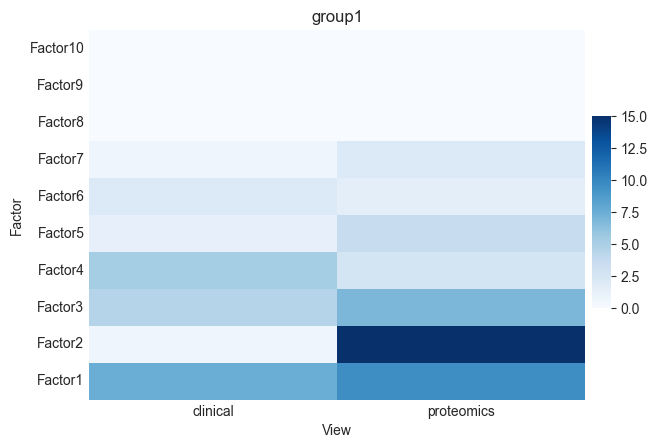

In [30]:
mofa.plot_r2(model, x='View', vmax=15)

<Axes: title={'center': 'clinical'}, xlabel='Feature weight'>

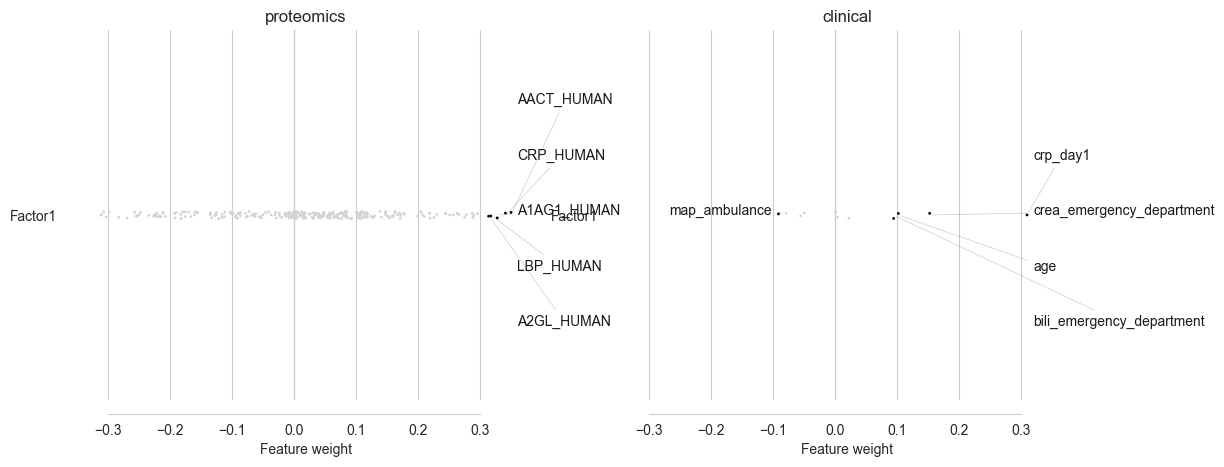

In [31]:
mofa.plot_weights(model, views=['proteomics', 'clinical'], factors=0, zero_line=True, ncols=2, label_size=10)

In [35]:
model.get_r2()

,Factor,View,Group,R2
0,Factor1,proteomics,group1,9.601067
1,Factor1,clinical,group1,7.505734
2,Factor2,proteomics,group1,15.534395
3,Factor2,clinical,group1,0.758264
4,Factor3,proteomics,group1,6.892228
5,Factor3,clinical,group1,4.556106
6,Factor4,proteomics,group1,2.720986
7,Factor4,clinical,group1,5.294488
8,Factor5,proteomics,group1,3.672333
9,Factor5,clinical,group1,1.265487


In [45]:
model.get_weights(
   #factors=[1],
    df=True
)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
AACT_HUMAN,0.349886,0.059438,-0.191734,0.072031,-0.000399,-0.033981,0.077033,1.492980e-14,-4.424357e-14,7.028189e-13
CRP_HUMAN,0.340898,-0.000034,-0.176539,0.149708,-0.047055,-0.263445,-0.049357,9.252415e-16,-2.996118e-15,4.481019e-14
A1AG1_HUMAN,0.327747,0.031106,-0.173721,-0.085975,0.000598,-0.001137,0.105990,-2.750777e-15,2.084959e-14,-1.666651e-13
LBP_HUMAN,0.317303,0.061357,-0.117869,0.180717,-0.057252,-0.258767,-0.058625,-1.173047e-14,2.355236e-14,-5.094280e-13
A2GL_HUMAN,0.313768,-0.028720,-0.117877,-0.001264,-0.050472,-0.225179,-0.046278,1.628859e-14,-1.351549e-14,6.412744e-13
crp_day1,0.309436,-0.038808,-0.202080,0.113072,-0.025057,-0.188712,-0.001140,-3.259398e-15,1.108780e-15,-1.378554e-13
FGL1_HUMAN,0.295931,0.052819,-0.200347,0.123853,-0.057180,-0.100709,-0.099018,2.779901e-14,-6.577298e-14,1.230562e-12
SAA1_HUMAN,0.289869,0.023813,-0.219132,0.166241,-0.067700,-0.325139,-0.096260,4.020179e-15,-8.558073e-15,1.762972e-13
SAA2_HUMAN,0.288118,0.000063,-0.214543,0.143827,-0.071122,-0.324474,-0.105336,8.651421e-16,-1.618022e-15,3.809520e-14
TIMP1_HUMAN,0.287576,0.098008,0.183448,0.055515,-0.026024,-0.113170,0.083467,4.029549e-16,-2.552652e-14,1.183756e-13


In [46]:

X_mofa = mdata.obsm['X_mofa']

In [47]:
mofa_columns = []

for i in range(X_mofa.shape[1]):

    mofa_col = f"MOFA {i}"

    mofa_columns.append(mofa_col)

    clinical_data_train[mofa_col] = X_mofa[:, i]

In [58]:
df_estimator = DigitalFamilyBinary(n_neighbors=5, neighbor_metric="euclidean")

In [59]:
df_estimator.fit(clinical_data_train, features=mofa_columns)

In [60]:
clinical_data_train['Resp Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="resp_dysfunction", bootstrap=False)

clinical_data_train['Renal Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="renal_dysfunction", bootstrap=False)

clinical_data_train['Cardio Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="cardiovasc_dysfunction", bootstrap=False)

clinical_data_train['Liver Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="liver_dysfunction", bootstrap=False)

clinical_data_train['CNS Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="cns_dysfunction", bootstrap=False)

clinical_data_train['Coag Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="coag_dysfunction", bootstrap=False)

In [61]:
display_columns = [
    "Resp Rate",
    "Renal Rate",
    "Cardio Rate",
    "Liver Rate",
    "CNS Rate",
    "Coag Rate",
]

In [62]:
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

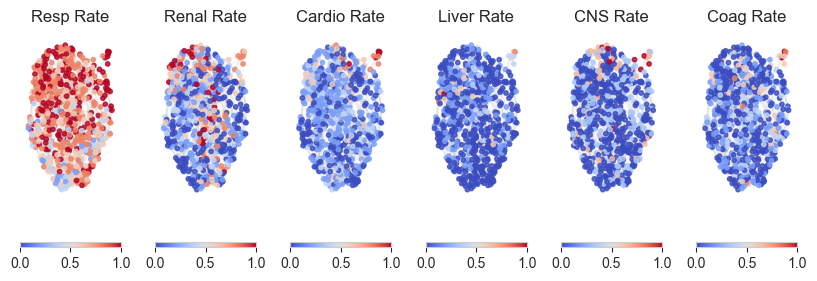

In [63]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=6
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(clinical_data_train[[col]])

    color_map = dict(zip(clinical_data_train.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27, 3))
plt.tight_layout()

<Axes: >

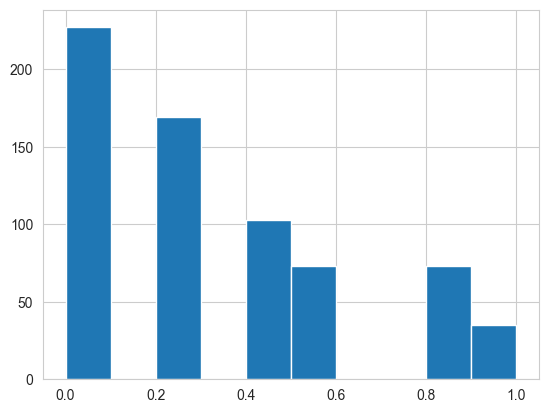

In [66]:
clinical_data_train['Renal Rate'].hist()